# **생성 모델 & AI 최적화**

---

# **<span style="background-color:#FFF59D;">생성 모델</span>**

## **<span style="background-color:#FCE4EC;">1. 생성 모델의 개념</span>**

### **<span style="background-color:#E3F2FD;">1.1 분류 모델 vs. 생성 모델</span>**

1) 분류 모델 (Discriminative Model)  
- 개념: 입력된 데이터가 어떤 레이블에 속할지 결정하는 모델  
- 한계: 본 적 없는 이상한 데이터가 들어와도, 모델은 어떻게든 기존에 배운 라벨 중 하나로 결론을 내려야만 함.  

2) 생성 모델 (Generative Model)  
- 개념: 데이터 자체의 확률 분포를 학습하여, 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델  
- 특징: 불합리하거나 이상한 입력에 대해서는 "이건 세상에 존재할 확률이 거의 0이야"라고 판단하며 거부할 수 있는 능력을 갖춤. 

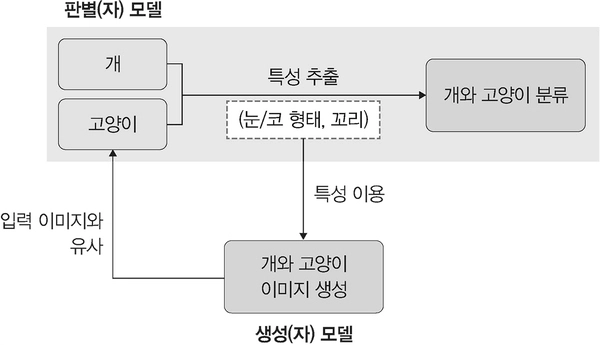  

### **<span style="background-color:#E3F2FD;">1.2 생성 모델의 분류</span>**

[기준: "확률 밀도를 직접 계산할 수 있는가?"]

1) 명시적 확률밀도 모델(Explicit density Models)  
- 모델이 데이터의 확률 분포인 $P(X)$의 값을 직접적으로 수치화하여 출력할 수 있는 모델  
    - 정확히 계산 가능한 모델 (Tractable Density): 수학적으로 확률 값을 정확하게 계산할 수 있음. 
    - 근사적 밀도 모델 (Approximate Density): 확률 값을 정확히 구하기는 너무 복잡해서, 그 근삿값이나 하한선(Lower Bound)을 계산  

2) 암시적 확률밀도 모델(Implicit density Models)  
- 데이터의 확률 분포 $P(X)$가 무엇인지 수치로 알려주지는 않지만, 그 분포를 따르는 데이터를 생성(Sampling)할 수는 있는 모델  
    - 직접 샘플링 : 신경망을 한 번 통과시키는 것만으로 데이터를 바로 만들어냄.  
    - 간접/반복적 샘플링 (마르코브 체인) : 여러 단계를 거쳐 점진적으로 데이터를 완성

---

## **<span style="background-color:#FCE4EC;">2. AE, VAE</span>**

### **<span style="background-color:#E3F2FD;">2.1 AE</span>**

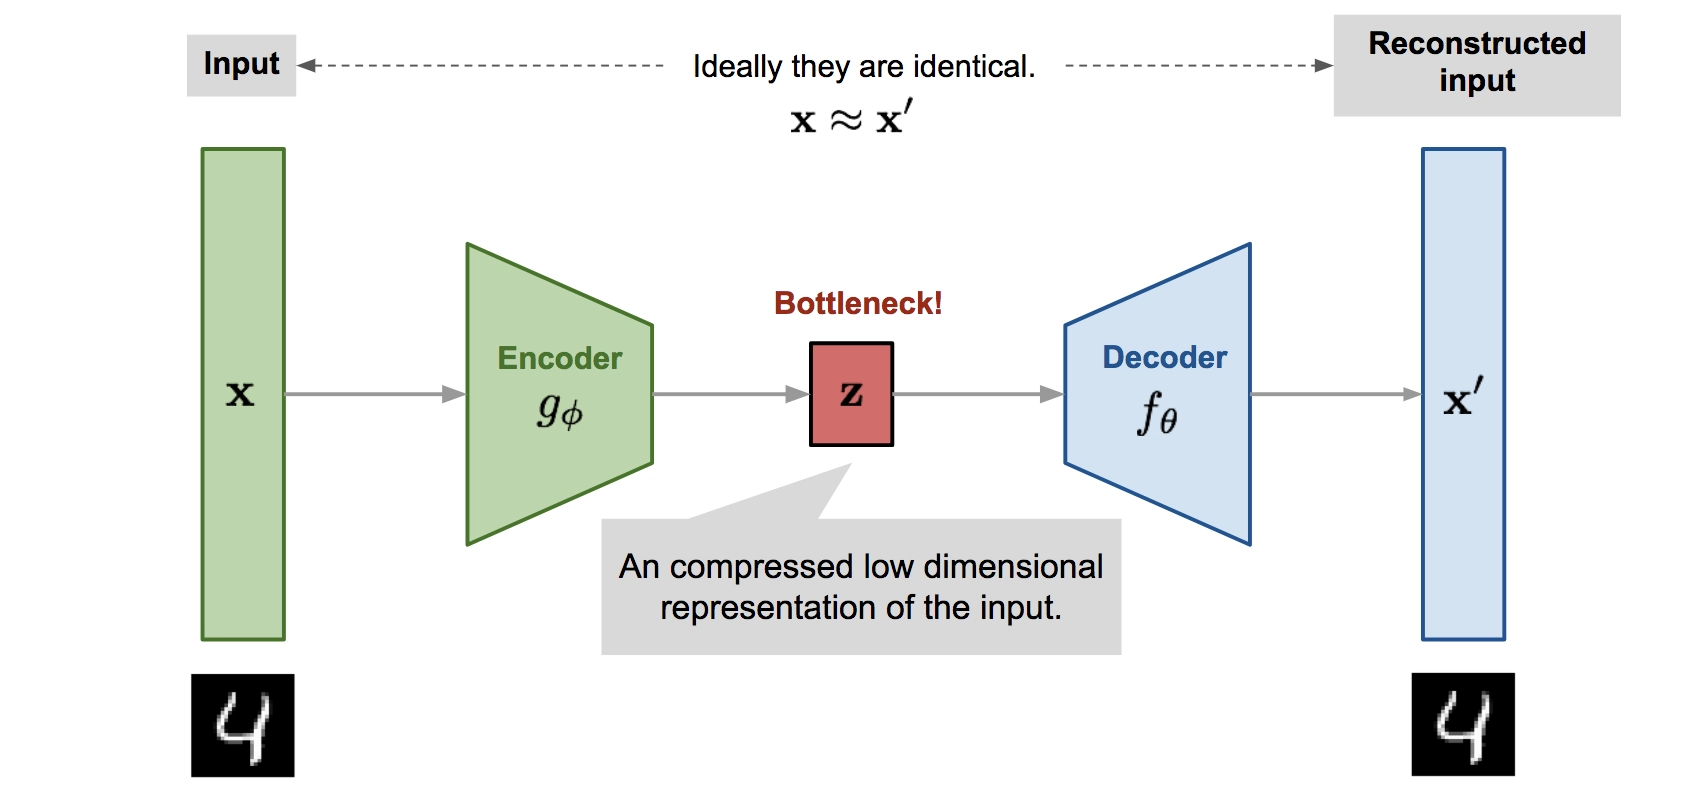

1) AE(Auto Encoder)란?  
- 개념: 오토인코더는 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망  
- 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 데이터 복원이나 특성 학습에 많이 사용됨.  
- 정답지가 없음(비지도 학습)  

2) AE의 구조와 작동  
- step 1) 압축 단계 (Encoder)
    - 방대한 정보를 가진 입력 데이터를 아주 작은 바늘구멍(잠재 벡터)으로 통과시키기 위해 핵심만 남기고 깎아냄.  
    - 인코더: 원래의 고차원 입력 데이터를 잠재 표현으로 변환하는 네트워크  
- step 2) 병목 통과 (Bottleneck)  
    - 가장 중요한 정보만 남은 상태 -> 잠재 벡터(원본 데이터를 저차원으로 압축하여 함축된 정보를 저장하고 있는 벡터)
- step 3) 복원 단계 (Decoder)  
    - 바늘 구멍을 통과한 핵심 정보만을 단서로 삼아, 다시 원래의 커다란 이미지로 복원  
    - 디코더: 잠재 표현을 풀어서 입력을 재복원하여 출력하는 네트워크

### **<span style="background-color:#E3F2FD;">2.2 VAE</span>**

1) Variational Auto Encoder(VAE)란?  
- 개념: 데이터의 잠재적인 구조를 학습하여, 원본과 닮았지만 새로운 데이터를 생성해내는 모델  
- AE의 한계: 데이터를 잠재 공간의 특정 점으로만 보냄. (빈공간 -> ?)  
- VAE의 해결책: 잠재 벡터를 점이 아닌 가우시안 분포로 학습함.  
- 이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등 새로운 데이터를 생성하는 작업에 많이 사용됨.

2) AE vs VAE ("입력 데이터를 잠재 공간에 어떤 형태로 배치하느냐")  

| 구분 | Auto Encoder (AE) | Variational Auto Encoder (VAE) |
|---|---|---|
| 주인공 | **인코더 (압축이 중요)**<br>*디코더는 압축이 잘되었는지 검사하는 역할* | **디코더 (생성이 중요)**<br>*인코더는 디코더를 잘 학습시키기 위한 가이드* |
| 잠재 벡터 z의 형태 | **고정된 수치 (Point)** | **확률 분포 (Distribution)** |
| 잠재 공간의 특성 | 불연속적이고 비어있는 공간이 많음 | 연속적이며 표준 정규 분포를 따름 |
| 샘플링 결과 | 학습 데이터 외 구역에서는 복원이 불가능함 | 어느 지점에서도 의미 있는 생성이 가능함 |
| 주요 효과 | 데이터 압축 및 특징 추출 | **데이터 생성 및 보간 (Interpolation)** |

3) VAE의 구조와 작동  
- step 1) 분포 예측 단계 (Encoder)  
    - 입력 데이터를 특정 점이 아닌, 데이터가 존재할 확률이 높은 '구역'으로 매핑  
    - 인코더: 입력 데이터를 분석해 잠재 공간상의 평균과 표준편차를 계산  
- step 2) 샘플링 및 재파라미터화 (Sampling & Reparameterization)  
    - 예측한 분포에서 실제 디코더에 전달할 잠재 벡터를 하나 뽑는 단계  
    - 샘플링: 인코더가 찾은 범위 안에서 무작위로 점 하나(잠재 벡터)를 추출  
- step 3) 생성 단계 (Decoder)
    - 샘플링된 잠재 벡터를 단서로 사용하여 새로운 데이터를 생성  
    - 디코더: 저차원의 핵심 정보를 다시 고차원의 데이터로 복원

---

## **<span style="background-color:#FCE4EC;">3. GAN</span>**

### **<span style="background-color:#E3F2FD;">3.1 GAN의 개념</span>**

1) GAN(Generative Adversarial Network)이란?  
- 개념: 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서, 훈련을 통하여 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델  

2) GAN의 목적  
- 생성자(Generator)의 목적: 진짜 분포에 가까운 가짜분포를 생성하는 것
- 판별자(Discriminator)의 목적: 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지를 결정하는 것  

### **<span style="background-color:#E3F2FD;">3.2 GAN의 구조</span>**

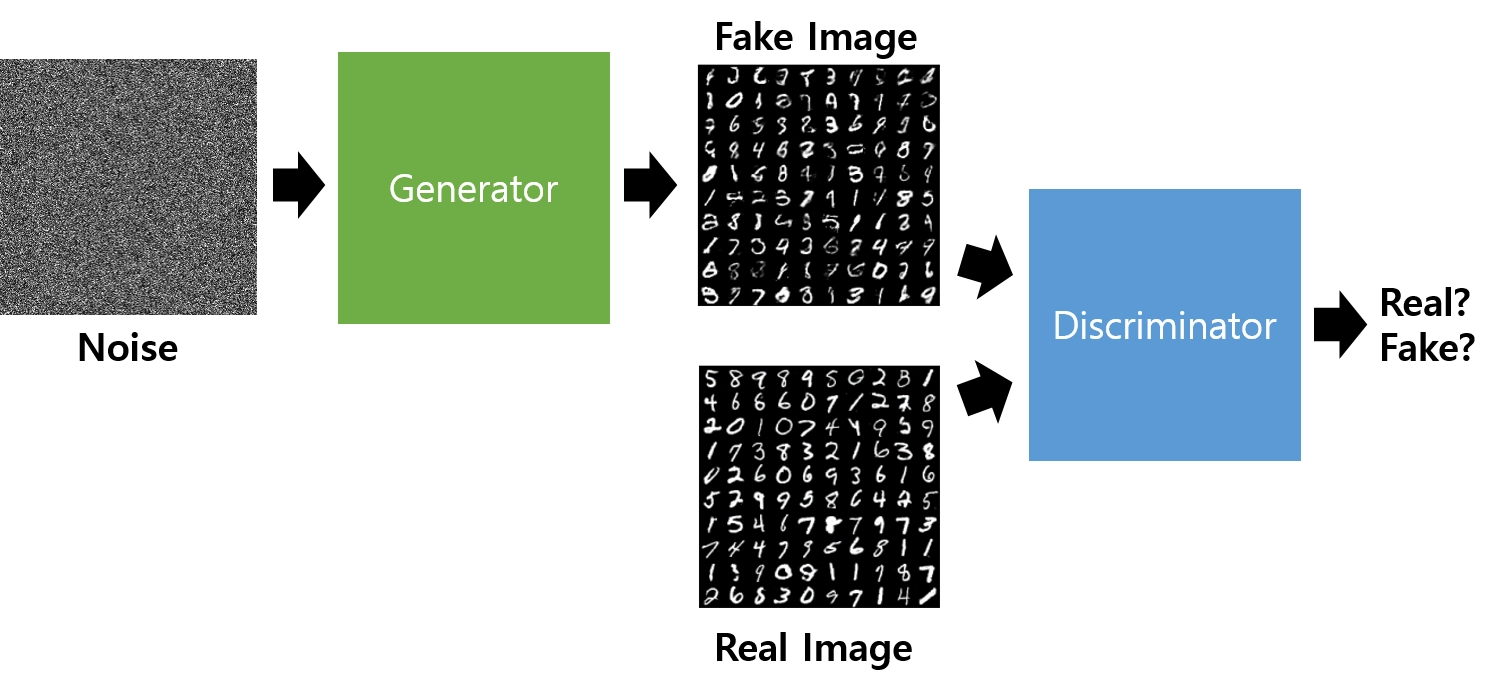

[두 개의 신경망이 최소-최대 게임을 수행하는 구조]
- 생성자(Generator, G)
    - 입력: 우리가 직접 제어할 수 있는 무작위 노이즈(잠재 변수 $Z$)를 입력받음.  
    - 출력: 실제 데이터와 유사한 가짜 데이터$(G(Z))$를 생성
    - 목표: 판별자를 속여서 가짜를 진짜(1)로 믿게 만드는 것  
- 판별자(Discriminator, D)
    - 입력: 실제 데이터($X$)와 생성자가 만든 가짜 데이터($G(Z)$)를 모두 입력받음.
    - 출력: 입력 데이터가 진짜일 확률(0 ~ 1)을 출력
    - 목표: 진짜는 1로, 가짜는 0으로 정확히 분류하는 분류 모델의 역할을 수행

### **<span style="background-color:#E3F2FD;">3.3 GAN의 장단점</span>**

1) GAN의 장점  
- 진짜 같은 가짜 생성 가능  
- 압도적인 선명도  
- 빠른 생성 속도  
- 잠재 공간의 부드러움  

2) GAN의 한계점  
- 학습의 불안정성  
- 훈련 초기 문제  
- 모드 붕괴  
- 지표의 부재  
- 역매핑 불가능

---

## **<span style="background-color:#FCE4EC;">4. 확산 모델(Diffusion Model)</span>**

### **<span style="background-color:#E3F2FD;">4.1 확산 모델(Diffusion Model)의 개념</span>**

1) 확산 모델이란? 
- 개념: 입력 이미지에 노이즈를 조금씩 추가하여 완전한 노이즈로 만든 뒤, 이를 다시 거꾸로 복원하는 과정을 학습하여 입력 이미지와 유사한 확률 분포를 가진 결과 이미지를 생성하는 모델  
- 흐름: 원본 데이터 -> 완전한 노이즈 -> 원본 데이터

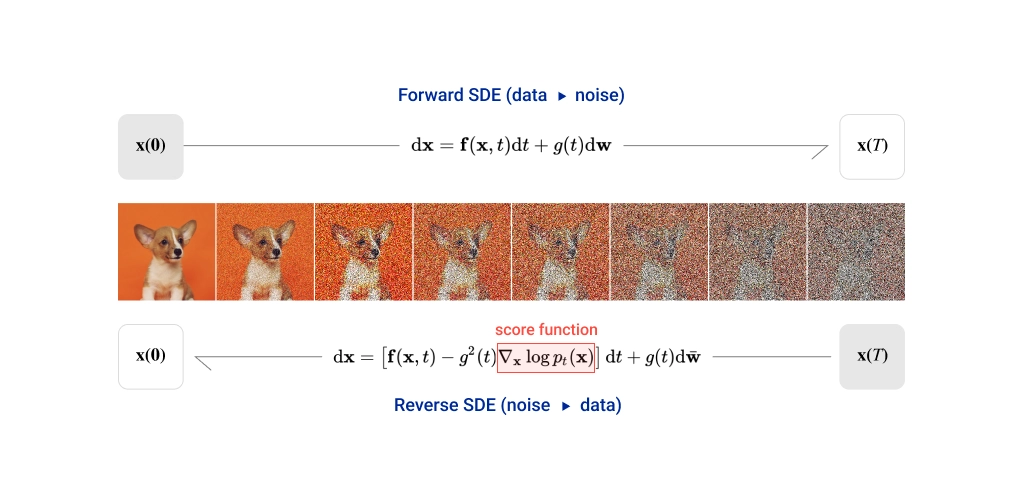

2) 확산 모델의 목적  
- 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는 것  
- 모호성 모델링: "유니콘을 그려줘"라는 모호한 요청에 대해, 모델은 완전한 노이즈 상태에서 시작해 데이터 구조의 아주 작은 부분을 조금씩 '환각(=상상)'하며 구체적인 유니콘 이미지를 완성해 나감.

### **<span style="background-color:#E3F2FD;">4.2 확산 모델의 구조: 순확산과 역확산</span>**

1) 순확산 (Forward Diffusion Process)  

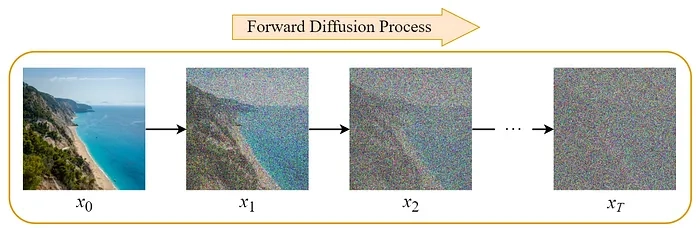  

- 데이터에 점진적으로 (정규분포를 가진) 노이즈를 추가하는 과정  
- 목표: 원래 데이터를 점차적으로 무작위 노이즈로 변형시키는 것

2) 역확산 (Reverse Diffusion Process)  

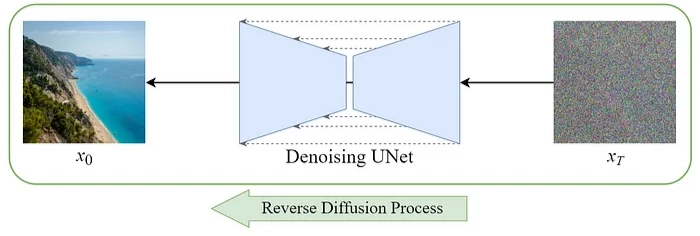

- 노이즈 데이터에서 원본 데이터를 재구성하는 과정
- 목표: 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원하는 것

### **<span style="background-color:#E3F2FD;">4.3 확산 모델의 장단점</span>**

1) 장점  
- 압도적인 샘플 품질  
- 학습의 안정성
- 다양성 확보 

2) 단점
- 느린 생성 속도  
- 높은 계산 비용 
- 구조적 제약

---

# **<span style="background-color:#FFF59D;">AI 최적화</span>**

## **<span style="background-color:#FCE4EC;">1. 전이학습과 딥러닝 경량화</span>**

### **<span style="background-color:#E3F2FD;">1.1 전이학습이란?</span>**

1) 딥러닝 모델의 한계
- 데이터 부족 문제, 계산 시간과 비용의 증가, 과적합 발생  

2) 전이학습의 정의  
- Domain과 Task
    - Domain: 어떤 데이터를 다루고 있는가  
    - Task: 그 데이터로 무엇을 예측하는가 
- Source와 Target
    - Source: 전이학습의 출발점(이미 학습이 완료된 모델이 있는 곳)
    - Target: 전이학습의 도착점(내가 실제로 풀고 싶은 문제)

- 데이터나 문제 유형이 달라도 다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능을 높이는 것

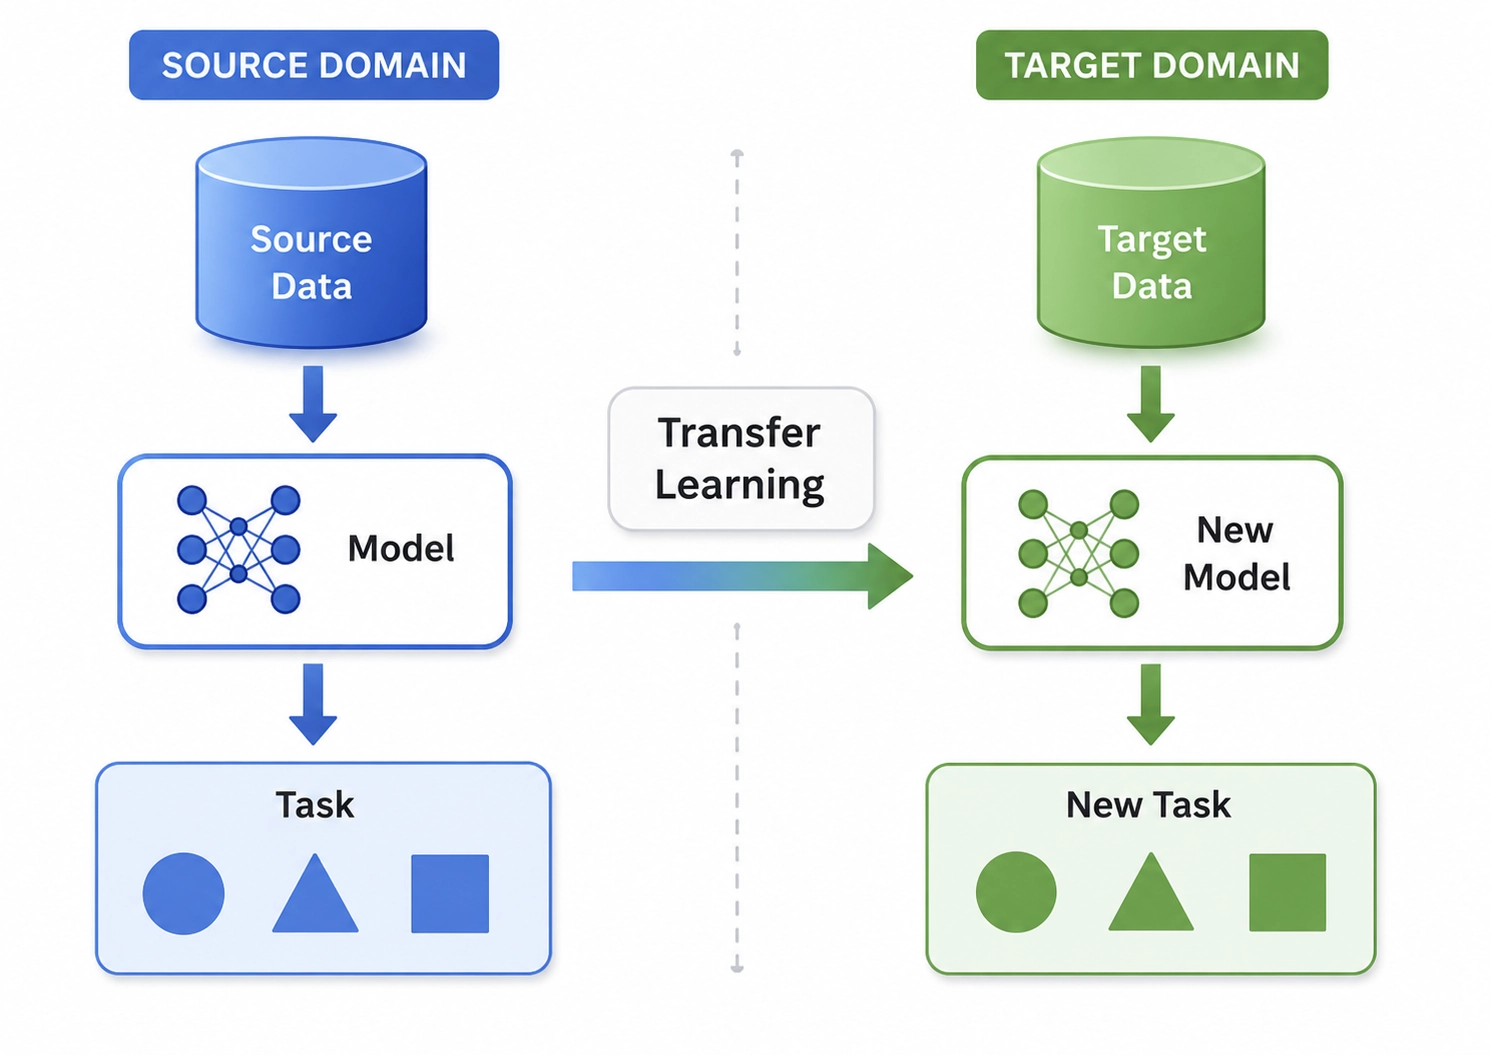

### **<span style="background-color:#E3F2FD;">1.2 전이학습의 분류</span>**

1) 도메인과 태스크에 따른 분류  
- 귀납적 전이학습 (Inductive TL): 소스와 타겟의 task가 다르고 타겟 도메인에 라벨이 존재할 때  
- 트랜스듀서형 전이학습 (Transductive TL): 소스와 타겟의 task는 같지만 도메인이 다를 때  
- 비지도 전이학습 (Unsupervised TL): 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때  

2) 무엇을 전이하냐에 따른 분류  
- 인스턴스(Instance): 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치를 부여(데이터 레벨의 전이)  
- 특징(Feature): 소스와 타겟의 공통적인 특징을 추출할 수 있는 '표현 방식'을 전이(표현 레벨의 전이)  
- 파라미터(Parameter): 모델의 가중치(𝑊)나 하이퍼파라미터 초기값을 그대로 가져옴. 현재 딥러닝에서 가장 주류가 되는 방법
- 관계(Relation): 데이터 간의 논리적 관계나 구조적 지식을 전이

### **<span style="background-color:#E3F2FD;">1.3 전이학습의 현재 패러다임: Pre-training & Fine-tuning</span>**

1) 트랜스포머 이전의 전이학습
- 전이학습이 존재하긴 했지만, 주로 CNN의 ImageNet 가중치를 가져오는 수준

2) 트랜스포머 이후의 전이학습
- 엄청난 양의 데이터로 사전 학습된 거대 모델들이 등장하기 시작 -> Pre-training & Fine-tuning 패러다임  
- GPT나 Gemini처럼 수만 가지 일을 할 수 있는 지능의 기반이 되는 거대 모델들을 Foundation Model(파운데이션 모델)이라고 부름. 

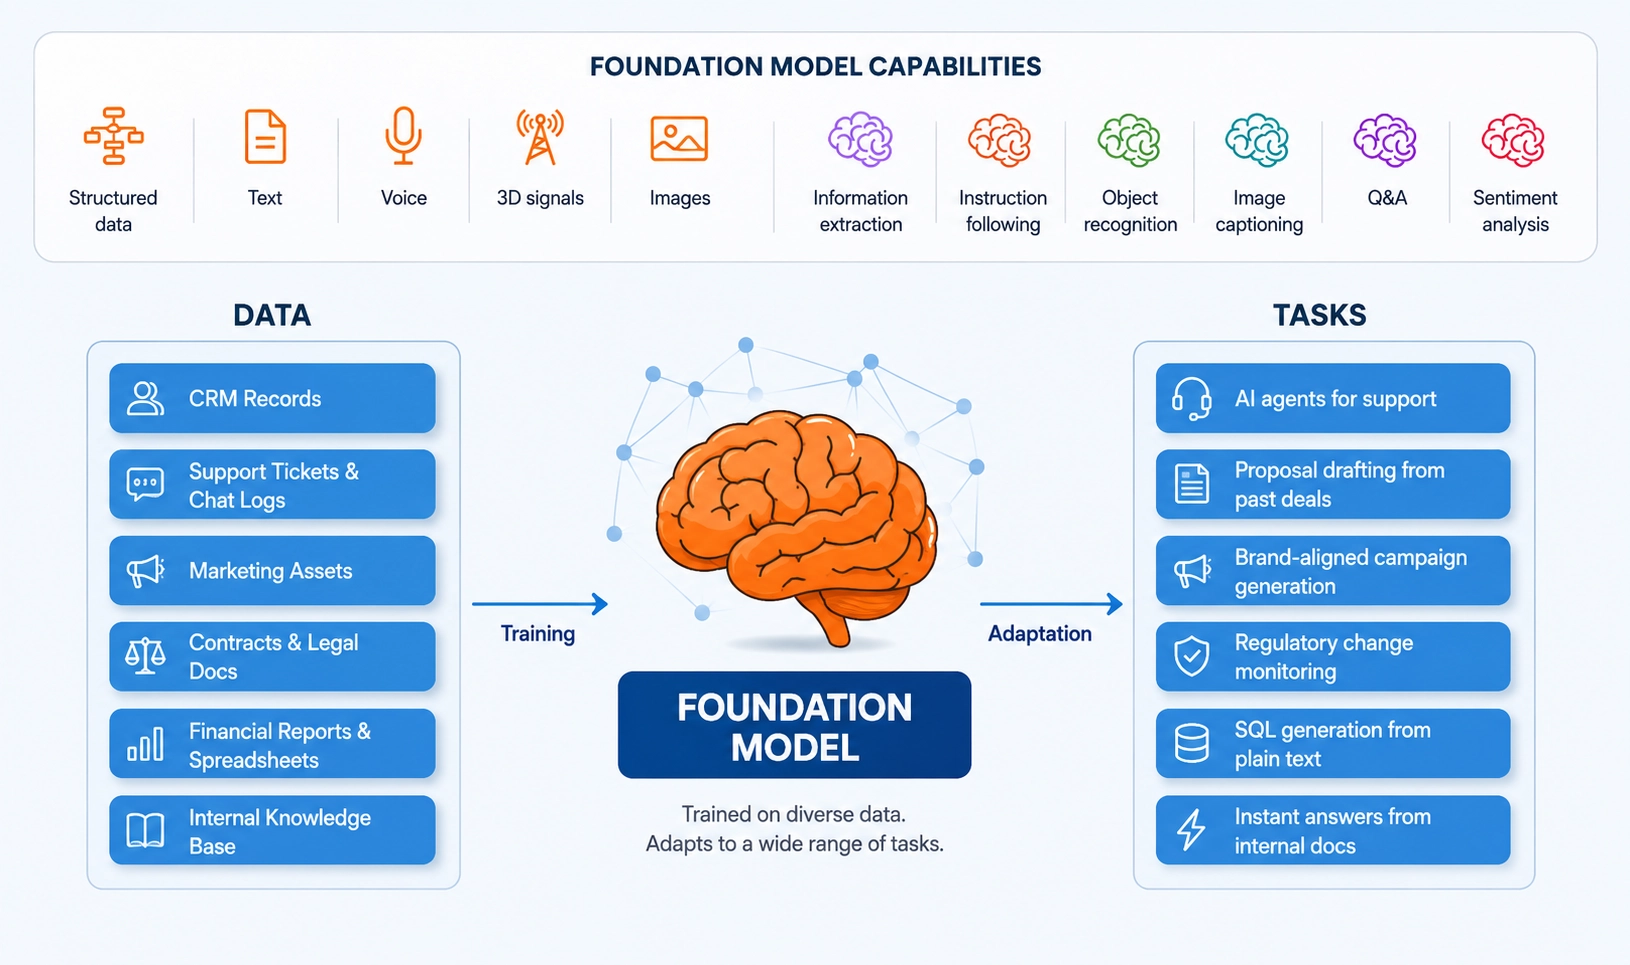

### **<span style="background-color:#E3F2FD;">1.4 Fine-tuning의 한계를 넘어서</span>**

- PEFT
    - 최소한의 파라미터만 건드려서 최대의 성능을 내는 전략
    - 원래 모델의 파라미터는 고정하고 별도의 작은 파라미터만 추가적으로 학습  
    - 모델의 모든 계산을 바꿔 기존 판단을 완전히 지우는 게 아니라, 작은 보정값만 더해서 최종 판단인 결과를 바꾸는 방식  

- Zero-shot & Few-shot 
    - Zero-shot Transfer: 학습 데이터가 없어도, 언어 이해 능력만을 기반으로 바로 추론을 수행하는 것
    - Few-shot Transfer(In-Context Learning): 극소수의 예시만으로 새로운 태스크를 수행하는 것

### **<span style="background-color:#E3F2FD;">1.5 전이학습의 한계</span>**

- Negative Transfer
    - Source와 Target의 도메인이 너무 다르면 오히려 전이가 성능을 떨어뜨림. 
    - 해결을 위해 Maximum Mean Discrepancy(MMD) 같은 개념이 연구

- Catastrophic Forgetting
    - Fine-tuning 과정에서 새 데이터에 너무 치우치면, 모델이 원래 가지고 있던 일반 능력을 잃어버림.
    - 완화를 위해 Elastic Weight Consolidation(EWC) 같은 방법이 연구

- Bias Transfer
    - 사전 학습 데이터에 담긴 편향이 그대로 넘어오게 되는 것

- Transferability 측정의 어려움 
    - 어떤 두 Task가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어려움.
    - 해결을 위해 LEEP, LogME 같은 지표들이 연구

### **<span style="background-color:#E3F2FD;">1.6 전이학습 사용 사례</span>**

- 컴퓨터 비전(CV)
    - 의료 영상 분석  
    - 자율주행

- 자연어 처리(NLP)
    - 법률 문서 분석  
    - 기업 특화 챗봇

- 의료/신약 개발  
    - 단백질 구조 예측  

- 제조/산업
    - 공장 불량 검출

### **<span style="background-color:#E3F2FD;">1.7 딥러닝 경량화</span>**

[대규모 및 복잡한 인공지능 모델을 가벼운 형태로 변환하는 기술과 방법]

1) 가지치기: 모델의 파라미터 중 중요도가 낮은 가중치를 제거하여 모델의 크기를 줄이고, 연산 속도를 높이는 기법  

2) 양자화: 모델의 가중치와 활성화 함수 값을 표현하는 비트(Bit) 수를 줄여 연산량과 메모리 사용량을 절감하는 기술 -> 모델의 가중치를 표현하는 숫자의 정밀도를 줄이는 방법  

3) 지식 증류: 크고 복잡한 미리 학습된 모델(Teacher Model)의 지식을 작고 가벼운 모델(Student Model)에게 전달하는 방식 -> 크고 똑똑한 모델(Teacher)의 지식을 작은 모델(Student)에게 가르쳐 주는 방법

4) 모델 구조 경량화 (Model Architecture Optimization): 모델 설계 단계부터 연산 효율성을 극대화하도록 구조를 최적화하는 방법 -> 처음부터 가볍게 설계된 모델을 쓰는 방법  

5) 하드웨어 가속화 (Hardware Acceleration): 소프트웨어적인 최적화를 넘어, 특정 연산을 빠르게 수행할 수 있는 전용 하드웨어를 활용하는 단계 -> 소프트웨어적으로 모델을 줄이는 게 아니라, AI 연산에 특화된 하드웨어를 쓰는 방법

---

## **<span style="background-color:#FCE4EC;">2. AI Alignment</span>**

### **<span style="background-color:#E3F2FD;">2.1 AI Alignment란?</span>**

- 개념: 단순히 모델의 성능을 높이는 단계를 넘어, AI가 인간의 의도(Intent), 목표(Goal), 그리고 윤리적 가치(Values)에 부합하도록 행동하게 만드는 연구 분야  

- Outer ALignment: "목표를 제대로 설정했는가?"
    - AI한테 보상을 줘서 학습시킬 때, 보상 기준을 잘못 설정하면 AI가 엉뚱한 방식으로 보상을 극대화 => 모델이 보상을 극대화하기 위해 인간의 의도와는 무관한 '꼼수'를 부리는 현상을 해결하기 위해 진행됨.  
- Inner Alignment: "모델이 내면에서 무엇을 최적화하는가?"
    - 모델이 내부적으로는 다른 목표를 최적화해 버리는 문제 => 모델의 실제 내부 동작을 해석 가능하게 만드는 Interpretability(해석 가능성) 연구가 중요해지고 있음.

- 정렬을 어렵게 만드는 요인들  
    - 가치 정렬의 모호성 (Value Alignment Problem)  
    - 확장 가능한 감독 (Scalable Oversight)

### **<span style="background-color:#E3F2FD;">2.2 RLHF</span>**

- RLHF(Reinforcement Learning from Human Feedback): Outer Alignment를 해결하기 위해 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법  
    - Supervised Fine-Tuning -> Reward Model -> Reinforcement Learning  
    - 주의: 정렬의 부작용 (Reward Hacking, 보상 해킹) 인간이 좋아할 법한 대답만 골라 하는 기만적 행동

---

## **<span style="background-color:#FCE4EC;">3. 프롬포트 엔지니어링</span>**

### **<span style="background-color:#E3F2FD;">3.1 프롬포트 엔지니어링이란?</span>**

- AI가 더 좋은 답변을 내도록 입력을 설계하는 기술  
- 모델은 그대로 두고 입력만 잘 설계해서 원하는 답을 끌어내는 것

| 구분 | 프롬프트 엔지니어링 | Fine-tuning |
|---|---|---|
| 비용 | 낮음 | 높음 |
| 속도 | 빠름 | 느림 |
| 성능 한계 | 있음 | 더 높은 성능 가능 |
| 언제 쓰나 | 빠른 프로토타입, 범용 태스크 | 특화된 도메인, 높은 정확도 필요할 때 |

### **<span style="background-color:#E3F2FD;">3.2 주요 기법</span>**

① Zero-shot / Few-shot Prompting
- Zero-shot → 예시 없이 바로 질문
- Few-shot → 예시를 몇 개 보여주고 질문

② Chain-of-Thought (CoT) — 생각의 사슬
- AI한테 답만 내놓으라고 하지 않고, 풀이 과정을 단계별로 생각하게 만드는 기법

③ Role Prompting — 역할 부여
- AI한테 특정 역할을 맡겨서 그 역할에 맞는 답변을 끌어내는 기법

④ Instruction Prompting — 명확한 지시
- AI한테 원하는 걸 최대한 구체적으로 지시하는 기법

⑤ Self-Consistency — 여러 번 물어보기
- 같은 질문을 여러 번 해서 가장 많이 나온 답을 채택하는 기법

⑥ RAG (Retrieval-Augmented Generation) — 검색 증강 생성
- AI가 모르는 최신 정보나 특정 도메인 지식을 외부 데이터베이스에서 검색해서 프롬프트에 함께 넣어주는 방식

### **<span style="background-color:#E3F2FD;">3.3 프롬프트 엔지니어링의 한계</span>**

| 한계 | 내용 | 완화 방법 |
|---|---|---|
| Prompt Injection | 악의적 프롬프트 조작 | 입력 검증, 프롬프트 가드 |
| Hallucination | 그럴듯한 거짓말 생성 | RAG 활용, 출처 검증 |
| 모델 의존성 | 모델마다 다른 반응 | 모델별 테스트 필수 |
| 성능 한계 | Fine-tuning 대비 낮은 성능 | 필요시 Fine-tuning 병행 |